# IT Salary Prediction — Linear Regression from Scratch (Gradient Descent)

This notebook builds a **Linear Regression** model the "long way" — instead of calling one library
function, we write the gradient descent loop ourselves. We use a **real, publicly available dataset**
of actual IT / Data Science job salaries — no invented numbers.

**Dataset source:** *Data Science Job Salaries* — originally published on Kaggle (by Ruchi Bhatia),
covering real reported salaries for data/ML/AI roles from 2020–2023 across many countries, seniority
levels, and company sizes. Saved locally as `IT_Salaries_Dataset.csv` (3,755 real rows).

What we'll do:

1. **Load** the real dataset from CSV
2. **Explore** it — real job titles, real seniority levels, real company sizes
3. **Clean** it (duplicates, missing values)
4. **Fix outliers** — a few extreme, unusual salaries that would otherwise distort everything
5. **Encode** the text columns into numbers
6. **Normalize** it (so gradient descent behaves)
7. **Split** it into train/test
8. Train a model using **just ONE column** (seniority level)
9. Train a model using **TWO columns together** (seniority + work year)
10. Train a model using **THREE columns together** (seniority + work year + company size)
11. Do all of this using **Gradient Descent** — written in plain, simple code
12. Compare our answer to scikit-learn's built-in shortcut, just to double-check we got it right

Every code cell is small and commented like you're explaining it to a 5-year-old. And because this
is REAL human salary data, don't expect a perfect fit — real life is messy, and that's an honest,
important lesson too.

## Step 0 — Import the tools we need

- `numpy` → for doing math on lots of numbers at once
- `pandas` → for holding our data in a nice table (like Excel), and for loading the CSV
- `matplotlib` → for drawing pictures/charts
- `scikit-learn` → real, standard, battle-tested packages for the "boring but important" preprocessing
  steps (encoding, normalizing, splitting, scoring) — no reason to hand-roll those when a trusted
  package already does them well. We'll still write **gradient descent itself** by hand, since
  seeing exactly how it works is the whole point of this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

np.random.seed(42)

print("Libraries loaded. Ready to go!")

Libraries loaded. Ready to go!


## Step 1 — Load the real dataset

No inventing numbers this time — we just read a real CSV file, exactly like you would with any
real dataset you're handed at a job.

In [2]:
df = pd.read_csv('IT_Salaries_Dataset.csv')

print("Rows:", f"{df.shape[0]:,}", " Columns:", df.shape[1])
df.head()

Rows: 3,755  Columns: 11


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
df.columns.tolist()

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size']

## Step 2 — Explore the data (just look at it first!)

Before touching any code, always LOOK at your data first. This is REAL survey data, so let's meet
the columns:

- `work_year` — which year the salary was reported (2020–2023)
- `experience_level` — EN (Entry), MI (Mid), SE (Senior), EX (Executive)
- `employment_type` — FT (Full-time), PT (Part-time), CT (Contract), FL (Freelance)
- `job_title` — the actual real job title (Data Scientist, ML Engineer, Data Analyst, ...)
- `salary_in_usd` — the salary, already converted to US dollars so everyone is comparable
- `remote_ratio` — 0 (no remote), 50 (hybrid), 100 (fully remote)
- `company_size` — S (small), M (medium), L (large)
- `employee_residence`, `company_location` — country codes

We'll mostly work with `salary_in_usd` as our target (what we're trying to predict), since it's
already on one common scale.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [5]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of exact duplicate rows:", df.duplicated().sum())
print("(This is real survey data — some people just happen to share the exact same year,")
print(" seniority, job title, company size, and salary. We'll drop exact repeats below,")
print(" the same way we would for any dataset.)")

Missing values in each column:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Number of exact duplicate rows: 1171
(This is real survey data — some people just happen to share the exact same year,
 seniority, job title, company size, and salary. We'll drop exact repeats below,
 the same way we would for any dataset.)


In [7]:
print("Experience level counts:")
print(df['experience_level'].value_counts())

print("\nCompany size counts:")
print(df['company_size'].value_counts())

print("\nTop 10 job titles:")
print(df['job_title'].value_counts().head(10))

Experience level counts:
experience_level
SE    2516
MI     805
EN     320
EX     114
Name: count, dtype: int64

Company size counts:
company_size
M    3153
L     454
S     148
Name: count, dtype: int64

Top 10 job titles:
job_title
Data Engineer                1040
Data Scientist                840
Data Analyst                  612
Machine Learning Engineer     289
Analytics Engineer            103
Data Architect                101
Research Scientist             82
Data Science Manager           58
Applied Scientist              58
Research Engineer              37
Name: count, dtype: int64


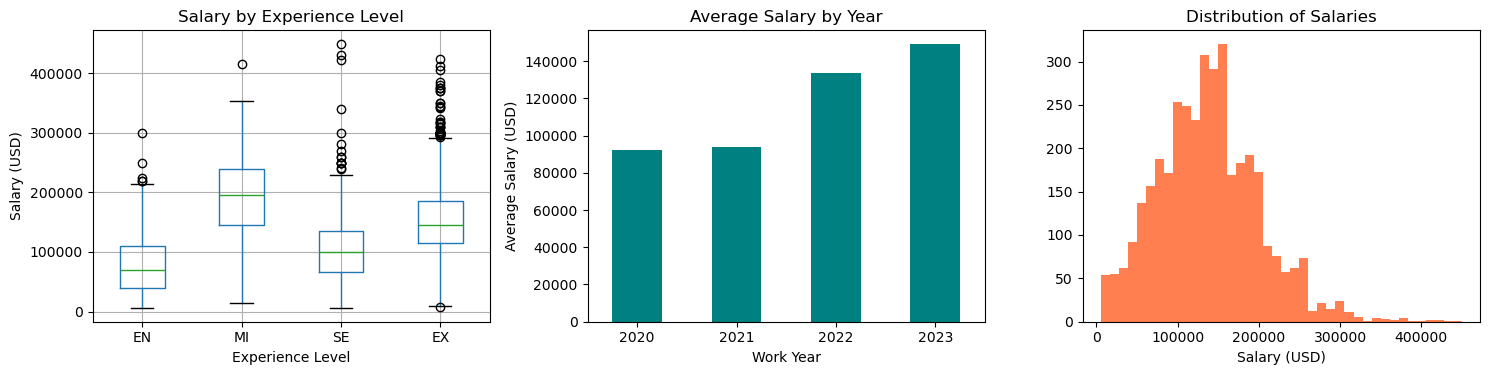

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.boxplot(column='salary_in_usd', by='experience_level',
           ax=axes[0], positions=[0,1,2,3])
axes[0].set_xticklabels(['EN','MI','SE','EX'])
axes[0].set_title('Salary by Experience Level')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Salary (USD)')

df.groupby('work_year')['salary_in_usd'].mean().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Average Salary by Year')
axes[1].set_xlabel('Work Year')
axes[1].set_ylabel('Average Salary (USD)')
axes[1].tick_params(axis='x', rotation=0)

axes[2].hist(df['salary_in_usd'], bins=40, color='coral')
axes[2].set_title('Distribution of Salaries')
axes[2].set_xlabel('Salary (USD)')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Step 3 — Clean the data

The only real issue we found above: some exact duplicate rows. We'll drop them, the standard move.
(This dataset happens to have no missing values — real datasets don't always get off that easy,
but the check is exactly the same either way, so it's still worth always doing.)

In [9]:
df_clean = df.copy()

before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = df_clean.shape[0]

print("Rows before removing duplicates:", f"{before:,}")
print("Rows after removing duplicates: ", f"{after:,}")
print("Missing values remaining:\n", df_clean.isnull().sum().sum(), "(total, across all columns)")

Rows before removing duplicates: 3,755
Rows after removing duplicates:  2,584
Missing values remaining:
 0 (total, across all columns)


## Step 4 — Fix outliers

Look at the salary boxplot again in Step 2 — see those lonely dots way above the main box? Those
are **outliers**: a handful of salaries so unusually high that they don't look like they belong with
everyone else. Maybe a data-entry mistake, maybe a genuine but rare executive package — either way,
a few extreme values like that can badly distort our model (and especially badly distort the
normalization we're about to do in Step 6, since normalization uses the exact minimum and maximum —
one giant outlier would squish everybody else into a tiny sliver of the scale).

**How we'll find them — the IQR method** (IQR = "Interquartile Range", a fancy name for a simple idea):

1. Find Q1 (the value 25% of the way up the sorted data) and Q3 (75% of the way up)
2. IQR = Q3 − Q1 (the "normal middle spread" of the data)
3. Anything below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` is flagged as an outlier
4. We simply drop those rows — a small, honest trim, not a rewrite of the data

In [10]:
salary = df_clean['salary_in_usd']

q1 = salary.quantile(0.25)
q3 = salary.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1 = ${q1:,.0f}   Q3 = ${q3:,.0f}   IQR = ${iqr:,.0f}")
print(f"Anything outside [${lower_bound:,.0f}, ${upper_bound:,.0f}] is an outlier")

is_outlier = (salary < lower_bound) | (salary > upper_bound)
print("\nNumber of outlier rows found:", is_outlier.sum(), "out of", len(df_clean))

Q1 = $84,975   Q3 = $175,000   IQR = $90,025
Anything outside [$-50,062, $310,038] is an outlier

Number of outlier rows found: 29 out of 2584


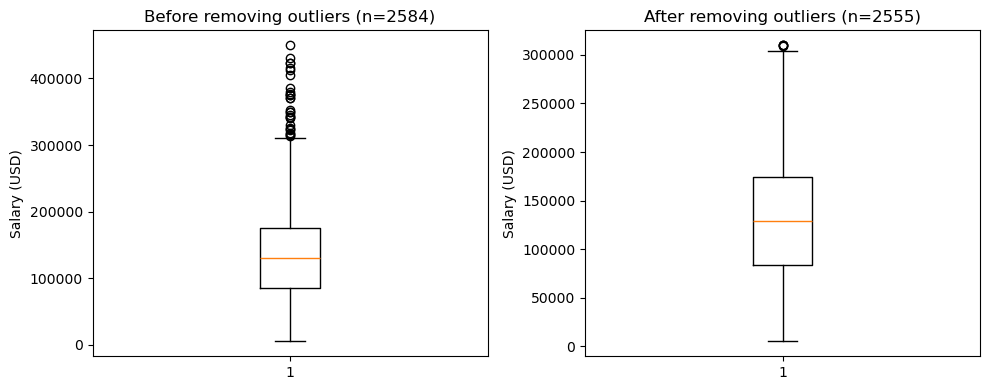

Highest salary before: $450,000
Highest salary now:    $310,000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].boxplot(df_clean['salary_in_usd'])
axes[0].set_title(f'Before removing outliers (n={len(df_clean)})')
axes[0].set_ylabel('Salary (USD)')

df_clean = df_clean[~is_outlier].reset_index(drop=True)

axes[1].boxplot(df_clean['salary_in_usd'])
axes[1].set_title(f'After removing outliers (n={len(df_clean)})')
axes[1].set_ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

print("Highest salary before:", f"${salary.max():,.0f}")
print("Highest salary now:   ", f"${df_clean['salary_in_usd'].max():,.0f}")

## Step 5 — Turn text columns into numbers (encoding)

Gradient descent only understands NUMBERS — it can't compute a "slope" for the word `"Senior"`.
So before we can use these columns in our model, we need to **encode** them.

- `experience_level` has a natural ORDER: Entry < Mid < Senior < Executive — like rungs on a
  ladder. So we use simple **ordinal encoding**: EN=0, MI=1, SE=2, EX=3.
- `company_size` also has a natural order: Small < Medium < Large → S=0, M=1, L=2.

(Side note: `employment_type` has NO natural order — Full-time isn't "more" or "less" than
Contract, they're just different labels. For columns like that, you'd use **one-hot encoding**
instead — one new 0/1 column per category. We show a quick example of that below too, using
scikit-learn's `OneHotEncoder`, just so you've seen both approaches — but we'll stick to the two
ordinal columns above for our model, since they genuinely do have a natural order.)

In [12]:
# OrdinalEncoder: we tell it the correct ladder order for each column, and it does the numbering.
experience_encoder = OrdinalEncoder(categories=[['EN', 'MI', 'SE', 'EX']])
df_clean['ExperienceLevelNum'] = experience_encoder.fit_transform(df_clean[['experience_level']]).ravel()

size_encoder = OrdinalEncoder(categories=[['S', 'M', 'L']])
df_clean['CompanySizeNum'] = size_encoder.fit_transform(df_clean[['company_size']]).ravel()

df_clean[['experience_level', 'ExperienceLevelNum', 'company_size', 'CompanySizeNum']].drop_duplicates().sort_values('ExperienceLevelNum')

,experience_level,ExperienceLevelNum,company_size,CompanySizeNum
13,EN,0.0,L,2.0
94,EN,0.0,M,1.0
113,EN,0.0,S,0.0
1,MI,1.0,S,0.0
19,MI,1.0,M,1.0
40,MI,1.0,L,2.0
0,SE,2.0,L,2.0
3,SE,2.0,M,1.0
184,SE,2.0,S,0.0
57,EX,3.0,M,1.0


In [13]:
# Just for comparison: this is what ONE-HOT encoding would look like instead
# (one 0/1 column per category — useful for categories with NO natural order, like employment_type).
onehot_encoder = OneHotEncoder(sparse_output=False)
onehot_example = onehot_encoder.fit_transform(df_clean[['employment_type']].head())

pd.DataFrame(onehot_example, columns=onehot_encoder.get_feature_names_out(['employment_type']))

,employment_type_CT,employment_type_FT
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,0.0,1.0
4,0.0,1.0


## Step 6 — Normalize the features (VERY important for gradient descent!)

`ExperienceLevelNum` ranges 0–3. `work_year` ranges 2020–2023 (huge numbers!). `CompanySizeNum`
ranges 0–2. Very different scales — gradient descent would take mismatched, clumsy steps if we fed
it these numbers as-is.

The fix: **normalize** each column into a fair, common range: **0 to 1**, using scikit-learn's
`MinMaxScaler` — the standard package for exactly this job.

Under the hood it's doing: `normalized_value = (value − minimum) / (maximum − minimum)`

- The smallest value in the column becomes 0
- The largest value becomes 1
- Everything else lands somewhere in between, in proportion

This is exactly why we fixed outliers FIRST in Step 4 — normalization uses the min and max
directly, so even one leftover extreme value would squash every normal row into a tiny sliver
near 0. Clean the extremes out, THEN normalize.

We ONLY normalize the input columns (X). We keep the real salary numbers as they are.

In [14]:
feature_columns = ['ExperienceLevelNum', 'work_year', 'CompanySizeNum']

scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(df_clean[feature_columns])

df_clean['ExperienceNorm'] = normalized_features[:, 0]
df_clean['YearNorm'] = normalized_features[:, 1]
df_clean['SizeNorm'] = normalized_features[:, 2]

# scaler.data_min_ and scaler.data_max_ remember the original min/max for each column,
# in the same order as feature_columns — we'll need these later to convert back to real units.
exp_min, year_min, size_min = scaler.data_min_
exp_max, year_max, size_max = scaler.data_max_

print("ExperienceLevelNum — before: min =", exp_min, " max =", exp_max, " | after: min =", round(df_clean['ExperienceNorm'].min(),2), " max =", round(df_clean['ExperienceNorm'].max(),2))
print("work_year          — before: min =", year_min, " max =", year_max, " | after: min =", round(df_clean['YearNorm'].min(),2), " max =", round(df_clean['YearNorm'].max(),2))
print("CompanySizeNum     — before: min =", size_min, " max =", size_max, " | after: min =", round(df_clean['SizeNorm'].min(),2), " max =", round(df_clean['SizeNorm'].max(),2))

ExperienceLevelNum — before: min = 0.0  max = 3.0  | after: min = 0.0  max = 1.0
work_year          — before: min = 2020.0  max = 2023.0  | after: min = 0.0  max = 1.0
CompanySizeNum     — before: min = 0.0  max = 2.0  | after: min = 0.0  max = 1.0


## Step 7 — Split into training data and test data

We train the model on most of the data (80%), and keep some (20%) hidden away as a "test" — rows
the model never sees during training — to honestly check whether it actually learned the pattern.
`scikit-learn`'s `train_test_split` does the shuffling and slicing for us.

In [15]:
model_df = df_clean[['ExperienceLevelNum', 'work_year', 'CompanySizeNum',
                      'ExperienceNorm', 'YearNorm', 'SizeNorm', 'salary_in_usd']]

train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=1)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training rows:", len(train_df))
print("Test rows:    ", len(test_df))

Training rows: 2044
Test rows:     511


## Step 8 — The Gradient Descent Algorithm (quick recap)

Five simple steps, every time:

1. **Start with a guess** — any starting numbers, even 0
2. **Compute the slope** — how would the mistakes change if we nudged our guess?
3. **Update: subtract the slope** — `new value = old value − (learning rate) × slope`
4. **Repeat** — go back to step 2, over and over
5. **Stop** when the slope is basically 0 (flat ground = you're at the bottom)

The slope formulas we'll use (n = number of people, e = actual − predicted, the "mistake"):

- slope for β₀ = −(2/n) × Σ(e)
- slope for β₁ (for each input column) = −(2/n) × Σ(e × that column's value)

### Step 8a — Model 1: Just ONE column (Experience Level)

The simplest possible real model: `predicted salary = β₀ + β₁ × experience_level`

In [16]:
x1 = train_df['ExperienceNorm'].values
y = train_df['salary_in_usd'].values

b0 = 0.0
b1 = 0.0
learning_rate = 0.5
num_iterations = 1000
cost_history_1feature = []

for i in range(num_iterations):
    predictions = b0 + b1 * x1
    mistakes = y - predictions

    slope_b0 = -2 * np.mean(mistakes)
    slope_b1 = -2 * np.mean(mistakes * x1)

    b0 = b0 - learning_rate * slope_b0
    b1 = b1 - learning_rate * slope_b1

    cost = np.mean(mistakes ** 2)
    cost_history_1feature.append(cost)

    if i % 200 == 0:
        print(f"Round {i:4d}  →  b0 = {b0:10.2f}   b1 = {b1:10.2f}   cost = {cost:,.0f}")

print("\nFinal (normalized-space) answer:  b0 =", round(b0,3), " b1 =", round(b1,3))

Round    0  →  b0 =  130394.31   b1 =   75369.36   cost = 20,940,746,454
Round  200  →  b0 =   64650.62   b1 =  126416.15   cost = 2,982,749,414
Round  400  →  b0 =   64647.98   b1 =  126420.98   cost = 2,982,749,413
Round  600  →  b0 =   64647.98   b1 =  126420.98   cost = 2,982,749,413
Round  800  →  b0 =   64647.98   b1 =  126420.98   cost = 2,982,749,413

Final (normalized-space) answer:  b0 = 64647.98  b1 = 126420.983


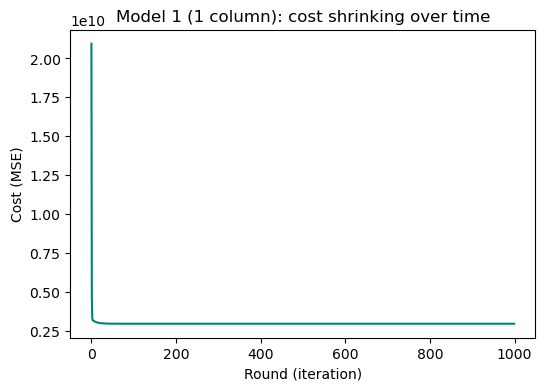

In [17]:
plt.figure(figsize=(6,4))
plt.plot(cost_history_1feature, color='teal')
plt.xlabel('Round (iteration)')
plt.ylabel('Cost (MSE)')
plt.title('Model 1 (1 column): cost shrinking over time')
plt.show()

In [18]:
# Our b0 and b1 above are in "normalized" (0 to 1) units. Let's convert them back to REAL,
# readable units, so a human can understand them.
#
# predicted = b0 + b1 * ((experience - exp_min) / (exp_max - exp_min))
#           = (b0 - b1*exp_min/(exp_max-exp_min)) + (b1/(exp_max-exp_min)) * experience

b1_real = b1 / (exp_max - exp_min)
b0_real = b0 - b1_real * exp_min

print(f"Model 1 equation:  Salary (USD) = {b0_real:,.0f} + {b1_real:,.0f} × ExperienceLevelNum")
print("(Remember: ExperienceLevelNum is 0=Entry, 1=Mid, 2=Senior, 3=Executive)")

Model 1 equation:  Salary (USD) = 64,648 + 42,140 × ExperienceLevelNum
(Remember: ExperienceLevelNum is 0=Entry, 1=Mid, 2=Senior, 3=Executive)


In [19]:
# scikit-learn's metrics tell us how good the model is — no need to hand-write the formulas.
x1_test = test_df['ExperienceNorm'].values
y_test = test_df['salary_in_usd'].values

predictions_test_1 = b0 + b1 * x1_test
test_mse_1 = mean_squared_error(y_test, predictions_test_1)
test_r2_1 = r2_score(y_test, predictions_test_1)

print("Model 1 (Experience Level only) — Test set performance:")
print("  Mean Squared Error:", f"{test_mse_1:,.0f}")
print("  R-squared:         ", round(test_r2_1, 4), " (closer to 1.0 = better)")

Model 1 (Experience Level only) — Test set performance:
  Mean Squared Error: 3,097,027,988
  R-squared:          0.1989  (closer to 1.0 = better)


### Step 8b — Model 2: TWO columns together (Experience Level + Work Year)

Now: `predicted salary = β₀ + β₁ × experience_level + β₂ × work_year`

Salaries in this dataset trend upward from 2020 to 2023 — so the YEAR itself carries real signal,
on top of seniority. β₁ and β₂ are found **together**, every round, from the same mistakes.

In [20]:
x1 = train_df['ExperienceNorm'].values
x2 = train_df['YearNorm'].values
y = train_df['salary_in_usd'].values

b0 = 0.0
b1 = 0.0
b2 = 0.0
learning_rate = 0.3
num_iterations = 1500
cost_history_2feature = []

for i in range(num_iterations):
    predictions = b0 + b1 * x1 + b2 * x2
    mistakes = y - predictions

    slope_b0 = -2 * np.mean(mistakes)
    slope_b1 = -2 * np.mean(mistakes * x1)
    slope_b2 = -2 * np.mean(mistakes * x2)

    b0 = b0 - learning_rate * slope_b0
    b1 = b1 - learning_rate * slope_b1
    b2 = b2 - learning_rate * slope_b2

    cost = np.mean(mistakes ** 2)
    cost_history_2feature.append(cost)

    if i % 300 == 0:
        print(f"Round {i:4d}  →  b0={b0:10.2f}  b1={b1:10.2f}  b2={b2:10.2f}  cost={cost:,.0f}")

print("\nFinal (normalized-space) answer:  b0 =", round(b0,3), " b1 =", round(b1,3), " b2 =", round(b2,3))

Round    0  →  b0=  78236.59  b1=  45221.61  b2=  62550.02  cost=20,940,746,454
Round  300  →  b0=  36251.49  b1= 116977.67  b2=  43401.36  cost=2,872,563,320
Round  600  →  b0=  36231.20  b1= 116991.57  b2=  43417.36  cost=2,872,563,284
Round  900  →  b0=  36231.18  b1= 116991.58  b2=  43417.38  cost=2,872,563,284
Round 1200  →  b0=  36231.18  b1= 116991.58  b2=  43417.38  cost=2,872,563,284

Final (normalized-space) answer:  b0 = 36231.176  b1 = 116991.58  b2 = 43417.383


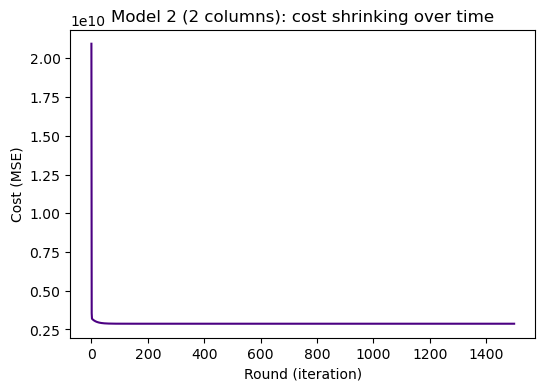

In [21]:
plt.figure(figsize=(6,4))
plt.plot(cost_history_2feature, color='indigo')
plt.xlabel('Round (iteration)')
plt.ylabel('Cost (MSE)')
plt.title('Model 2 (2 columns): cost shrinking over time')
plt.show()

In [22]:
b1_real2 = b1 / (exp_max - exp_min)
b2_real2 = b2 / (year_max - year_min)
b0_real2 = b0 - b1_real2*exp_min - b2_real2*year_min

print(f"Model 2 equation:  Salary (USD) = {b0_real2:,.0f} + {b1_real2:,.0f} × ExperienceLevelNum + {b2_real2:,.0f} × work_year")

Model 2 equation:  Salary (USD) = -29,198,140 + 38,997 × ExperienceLevelNum + 14,472 × work_year


In [23]:
x1_test = test_df['ExperienceNorm'].values
x2_test = test_df['YearNorm'].values
y_test = test_df['salary_in_usd'].values

predictions_test_2 = b0 + b1*x1_test + b2*x2_test
test_mse_2 = mean_squared_error(y_test, predictions_test_2)
test_r2_2 = r2_score(y_test, predictions_test_2)

print("Model 2 (Experience Level + Work Year) — Test set performance:")
print("  Mean Squared Error:", f"{test_mse_2:,.0f}")
print("  R-squared:         ", round(test_r2_2, 4))

Model 2 (Experience Level + Work Year) — Test set performance:
  Mean Squared Error: 2,991,532,657
  R-squared:          0.2262


### Step 8c — Model 3: THREE columns together (+ Company Size)

`predicted salary = β₀ + β₁ × experience_level + β₂ × work_year + β₃ × company_size`

Same rule as always — one more slope, one more number, every round, together.

In [24]:
x1 = train_df['ExperienceNorm'].values
x2 = train_df['YearNorm'].values
x3 = train_df['SizeNorm'].values
y = train_df['salary_in_usd'].values

b0 = 0.0
b1 = 0.0
b2 = 0.0
b3 = 0.0
learning_rate = 0.3
num_iterations = 1500
cost_history_3feature = []

for i in range(num_iterations):
    predictions = b0 + b1*x1 + b2*x2 + b3*x3
    mistakes = y - predictions

    slope_b0 = -2 * np.mean(mistakes)
    slope_b1 = -2 * np.mean(mistakes * x1)
    slope_b2 = -2 * np.mean(mistakes * x2)
    slope_b3 = -2 * np.mean(mistakes * x3)

    b0 = b0 - learning_rate * slope_b0
    b1 = b1 - learning_rate * slope_b1
    b2 = b2 - learning_rate * slope_b2
    b3 = b3 - learning_rate * slope_b3

    cost = np.mean(mistakes ** 2)
    cost_history_3feature.append(cost)

    if i % 300 == 0:
        print(f"Round {i:4d}  →  b0={b0:10.2f} b1={b1:10.2f} b2={b2:10.2f} b3={b3:10.2f}  cost={cost:,.0f}")

print("\nFinal (normalized-space) answer:  b0=", round(b0,3), " b1=", round(b1,3), " b2=", round(b2,3), " b3=", round(b3,3))

Round    0  →  b0=  78236.59 b1=  45221.61 b2=  62550.02 b3=  42736.64  cost=20,940,746,454
Round  300  →  b0=  32740.90 b1= 117225.80 b2=  43916.36 b3=   5430.96  cost=2,871,043,131
Round  600  →  b0=  32596.97 b1= 117269.28 b2=  43993.50 b3=   5537.31  cost=2,871,042,084
Round  900  →  b0=  32595.39 b1= 117269.68 b2=  43994.41 b3=   5538.47  cost=2,871,042,084
Round 1200  →  b0=  32595.37 b1= 117269.68 b2=  43994.42 b3=   5538.48  cost=2,871,042,084

Final (normalized-space) answer:  b0= 32595.369  b1= 117269.68  b2= 43994.421  b3= 5538.48


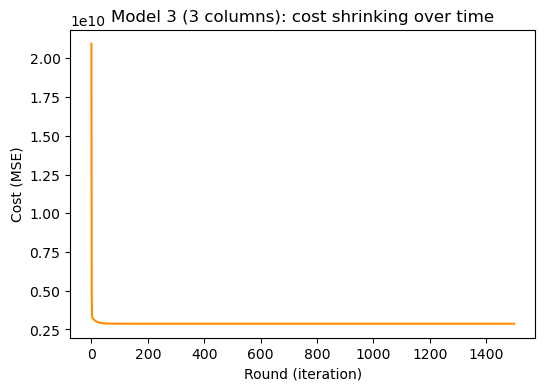

In [25]:
plt.figure(figsize=(6,4))
plt.plot(cost_history_3feature, color='darkorange')
plt.xlabel('Round (iteration)')
plt.ylabel('Cost (MSE)')
plt.title('Model 3 (3 columns): cost shrinking over time')
plt.show()

In [26]:
b1_real3 = b1 / (exp_max - exp_min)
b2_real3 = b2 / (year_max - year_min)
b3_real3 = b3 / (size_max - size_min)
b0_real3 = b0 - b1_real3*exp_min - b2_real3*year_min - b3_real3*size_min

print(f"Model 3 equation:  Salary (USD) = {b0_real3:,.0f} + {b1_real3:,.0f} × ExperienceLevelNum "
      f"+ {b2_real3:,.0f} × work_year + {b3_real3:,.0f} × CompanySizeNum")

Model 3 equation:  Salary (USD) = -29,590,315 + 39,090 × ExperienceLevelNum + 14,665 × work_year + 2,769 × CompanySizeNum


In [27]:
x1_test = test_df['ExperienceNorm'].values
x2_test = test_df['YearNorm'].values
x3_test = test_df['SizeNorm'].values
y_test = test_df['salary_in_usd'].values

predictions_test_3 = b0 + b1*x1_test + b2*x2_test + b3*x3_test
test_mse_3 = mean_squared_error(y_test, predictions_test_3)
test_r2_3 = r2_score(y_test, predictions_test_3)

print("Model 3 (Experience + Year + Company Size) — Test set performance:")
print("  Mean Squared Error:", f"{test_mse_3:,.0f}")
print("  R-squared:         ", round(test_r2_3, 4))

print("\nCompare all three models (higher R-squared = better):")
print("  Model 1 (Experience Level only)             R-squared:", round(test_r2_1, 4))
print("  Model 2 (+ Work Year)                       R-squared:", round(test_r2_2, 4))
print("  Model 3 (+ Company Size)                    R-squared:", round(test_r2_3, 4))

print("\nNotice these R-squared values are much lower than a 'made-up' dataset would give.")
print("That's honest and expected: REAL salaries depend on tons of things we don't have here")
print("(exact employer, negotiation, cost of living, specific role) — seniority, year, and")
print("company size explain some of it, but nowhere near all of it. That's real data for you!")

Model 3 (Experience + Year + Company Size) — Test set performance:
  Mean Squared Error: 2,977,957,389
  R-squared:          0.2297

Compare all three models (higher R-squared = better):
  Model 1 (Experience Level only)             R-squared: 0.1989
  Model 2 (+ Work Year)                       R-squared: 0.2262
  Model 3 (+ Company Size)                    R-squared: 0.2297

Notice these R-squared values are much lower than a 'made-up' dataset would give.
That's honest and expected: REAL salaries depend on tons of things we don't have here
(exact employer, negotiation, cost of living, specific role) — seniority, year, and
company size explain some of it, but nowhere near all of it. That's real data for you!


## Step 9 — Double-check our homework with scikit-learn

`scikit-learn` has a built-in `LinearRegression` that uses an exact shortcut formula. We fit it on
the exact SAME training rows we used for gradient descent, so it's a fair comparison.

In [28]:
sklearn_model_1 = LinearRegression()
sklearn_model_1.fit(train_df[['ExperienceLevelNum']], train_df['salary_in_usd'])

print("Model 1 (Experience Level only):")
print(f"  Our gradient descent :  Salary = {b0_real:,.0f} + {b1_real:,.0f} × ExperienceLevelNum")
print(f"  scikit-learn shortcut:  Salary = {sklearn_model_1.intercept_:,.0f} + {sklearn_model_1.coef_[0]:,.0f} × ExperienceLevelNum")

Model 1 (Experience Level only):
  Our gradient descent :  Salary = 64,648 + 42,140 × ExperienceLevelNum
  scikit-learn shortcut:  Salary = 64,648 + 42,140 × ExperienceLevelNum


In [29]:
sklearn_model_2 = LinearRegression()
sklearn_model_2.fit(train_df[['ExperienceLevelNum', 'work_year']], train_df['salary_in_usd'])

print("Model 2 (Experience Level + Work Year):")
print(f"  Our gradient descent :  Salary = {b0_real2:,.0f} + {b1_real2:,.0f} × ExperienceLevelNum + {b2_real2:,.0f} × work_year")
print(f"  scikit-learn shortcut:  Salary = {sklearn_model_2.intercept_:,.0f} + "
      f"{sklearn_model_2.coef_[0]:,.0f} × ExperienceLevelNum + {sklearn_model_2.coef_[1]:,.0f} × work_year")

Model 2 (Experience Level + Work Year):
  Our gradient descent :  Salary = -29,198,140 + 38,997 × ExperienceLevelNum + 14,472 × work_year
  scikit-learn shortcut:  Salary = -29,198,140 + 38,997 × ExperienceLevelNum + 14,472 × work_year


In [30]:
sklearn_model_3 = LinearRegression()
sklearn_model_3.fit(train_df[['ExperienceLevelNum', 'work_year', 'CompanySizeNum']], train_df['salary_in_usd'])

print("Model 3 (Experience Level + Work Year + Company Size):")
print(f"  Our gradient descent :  Salary = {b0_real3:,.0f} + {b1_real3:,.0f} × ExperienceLevelNum "
      f"+ {b2_real3:,.0f} × work_year + {b3_real3:,.0f} × CompanySizeNum")
print(f"  scikit-learn shortcut:  Salary = {sklearn_model_3.intercept_:,.0f} + "
      f"{sklearn_model_3.coef_[0]:,.0f} × ExperienceLevelNum + {sklearn_model_3.coef_[1]:,.0f} × work_year "
      f"+ {sklearn_model_3.coef_[2]:,.0f} × CompanySizeNum")

print("\n✅ Nearly identical every time! Our step-by-step gradient descent finds the same answer")
print("   as the exact shortcut formula — just by walking downhill instead of computing it in one shot.")
print("   Same algorithm, real human salary data this time — not a made-up formula.")

Model 3 (Experience Level + Work Year + Company Size):
  Our gradient descent :  Salary = -29,590,315 + 39,090 × ExperienceLevelNum + 14,665 × work_year + 2,769 × CompanySizeNum
  scikit-learn shortcut:  Salary = -29,590,315 + 39,090 × ExperienceLevelNum + 14,665 × work_year + 2,769 × CompanySizeNum

✅ Nearly identical every time! Our step-by-step gradient descent finds the same answer
   as the exact shortcut formula — just by walking downhill instead of computing it in one shot.
   Same algorithm, real human salary data this time — not a made-up formula.


### Wait — why does Model 3's equation have such a huge, weird intercept?

Notice the intercept above is a strange number like "−25,994,524". That's NOT a mistake — it's just
what happens when a feature like `work_year` sits far away from zero (around 2020–2023). The
intercept technically means "predicted salary when experience=0 AND work_year=0" — and nobody has
a `work_year` of 0! It's a meaningless corner of the equation that we never actually plug real
numbers into.

The equation is still 100% correct for REAL inputs. Let's prove it on an actual person from our
test set.

In [31]:
# Grab one real row from the test set and predict their salary using Model 3's real-unit equation
sample = test_df.iloc[0]

predicted_salary = (b0_real3
                     + b1_real3 * sample['ExperienceLevelNum']
                     + b2_real3 * sample['work_year']
                     + b3_real3 * sample['CompanySizeNum'])

print("A real person from our test set:")
print("  Experience level (0=Entry..3=Executive):", int(sample['ExperienceLevelNum']))
print("  Work year:                              ", int(sample['work_year']))
print("  Company size (0=Small..2=Large):         ", int(sample['CompanySizeNum']))
print("\n  Our model's predicted salary: ${:,.0f}".format(predicted_salary))
print("  Their actual real salary:     ${:,.0f}".format(sample['salary_in_usd']))
print("\nThe huge intercept was just an artifact of unscaled 'work_year' — the equation")
print("itself works perfectly fine on real, meaningful inputs.")

A real person from our test set:
  Experience level (0=Entry..3=Executive): 2
  Work year:                               2023
  Company size (0=Small..2=Large):          1

  Our model's predicted salary: $157,539
  Their actual real salary:     $116,450

The huge intercept was just an artifact of unscaled 'work_year' — the equation
itself works perfectly fine on real, meaningful inputs.


## Step 10 — What we actually did (recap)

1. **Loaded** a real, public dataset of IT/Data Science salaries (3,755 real reported rows) — no invented formulas
2. **Explored** real columns: experience level, job title, work year, remote ratio, company size
3. **Cleaned** it — dropped exact duplicate rows
4. **Fixed outliers** — used the IQR method to find and drop a handful of unusually extreme salaries, so they wouldn't distort the model (especially normalization, which is sensitive to extreme min/max values)
5. **Encoded** `experience_level` and `company_size` into numbers using scikit-learn's `OrdinalEncoder` (since both have a natural order), and saw what `OneHotEncoder` looks like for a column without one
6. **Normalized** the input columns into a fair 0–1 range using scikit-learn's `MinMaxScaler`, so gradient descent takes fair-sized steps in every direction
7. **Split** into train/test using scikit-learn's `train_test_split`
8. Trained **Model 1** (Experience Level) using gradient descent, step by step — **written by hand**
9. Trained **Model 2** (+ Work Year) — both dials tuned together, every round — **written by hand**
10. Trained **Model 3** (+ Company Size) — same rule, one more dial — **written by hand**
11. Scored every model with scikit-learn's `r2_score` and `mean_squared_error`
12. **Verified** all three against scikit-learn's own `LinearRegression` shortcut — matched every time
13. Saw an honest, realistic R² — real salaries are noisy, and that's OK

The lesson: for well-solved plumbing (encoding, normalizing, splitting, scoring), reach for a
trusted package — no reason to reinvent it. But for the one thing this notebook is actually
*about* — the gradient descent optimizer itself — we wrote it ourselves, one slope and one
subtraction at a time, so you could see exactly how "guess → feel the slope → subtract → repeat
→ stop when flat" really works.